In [26]:
# import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load only the train data
train_df=pd.read_csv(r"D:\Olist\train.csv")


# Data Types, Shape, and Memory
print(f"Rows count: {train_df.shape[0]:,}")
print(f"Columns cout: {train_df.shape[1]}")
print(f"{train_df.memory_usage(deep=True).sum()/ 1024**2:.2f} MB")

Rows count: 79,552
Columns cout: 24
73.43 MB


In [28]:
# Function to save EDA charts
output_dir="eda_charts"
os.makedirs(output_dir,exist_ok=True)

def save_chart(filename):
    filepath=os.path.join(output_dir,filename)
    fig = plt.gcf()
    plt.savefig(filepath,bbox_inches="tight",dpi=300)
    print(f"Saved: {filepath}")
    plt.close(fig)

In [29]:
# Data structure information:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79552 entries, 0 to 79551
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       79552 non-null  str    
 1   customer_id                    79552 non-null  str    
 2   order_status                   79552 non-null  str    
 3   order_purchase_timestamp       79552 non-null  str    
 4   order_approved_at              79465 non-null  str    
 5   order_delivered_carrier_date   78002 non-null  str    
 6   order_delivered_customer_date  76980 non-null  str    
 7   order_estimated_delivery_date  79552 non-null  str    
 8   customer_unique_id             79552 non-null  str    
 9   customer_zip_code_prefix       79552 non-null  int64  
 10  customer_city                  79552 non-null  str    
 11  customer_state                 79552 non-null  str    
 12  total_price                    78883 non-null  float64
 1

In [30]:
# Summary statistics of numerical and categorical columns:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,79552,79552,2e7a8482f6fb09756ca50c10d7bfc047,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,79552,79552,08c5351a6aca1c1589a38f244edeee9d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,79552,8,delivered,76976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,79552,79088,2017-11-20 10:59:08,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,79465,73535,2018-02-27 04:31:10,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,78002,69876,2018-05-09 15:48:00,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,76980,76329,2016-10-27 17:32:07,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,79552,395,2017-12-20,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,79552,76953,8d50f5eadf50201ccdcedfb9e2ac8455,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,79552.0,NaN,NaN,NaN,35672.197343,29844.755187,1003.0,11730.0,25527.5,59998.75,99990.0


### Missing values: how many, where, and is the missing itself meaningful

#### Structural Missingness (Missingness as a Condition):
In real estate datasets, if the (Pool Area) column is empty, it usually doesn't mean the data was lost accidentally it typically means "there is no pool in the house.
#### User Behavior or Response Dynamics:
In surveys, skipping a question like (Income) might indicate a very high income level, concerns regarding privacy, or refusal to disclose personal financial information.
#### Time or Event-Dependent Data:
In medical datasets, the absence of a specific test result often means the doctor never ordered the test in the first place because the patient was healthy and exhibited no symptoms.

In [31]:
# Missing values count and percentage
missing_count=train_df.isnull().sum()
missing_pct=(missing_count / len(train_df) * 100).round(2)
missing_summary=pd.DataFrame({
    "missing_count":missing_count,
    "missing_pct":missing_pct
}).sort_values("missing_count",ascending=False)
missing_summary=missing_summary[missing_summary['missing_count'] > 0]
print(missing_summary)

                               missing_count  missing_pct
order_delivered_customer_date           2572         3.23
order_delivered_carrier_date            1550         1.95
total_price                              669         0.84
max_item_price                           669         0.84
seller_id                                669         0.84
total_items                              669         0.84
total_freight                            669         0.84
min_item_price                           669         0.84
avg_item_price                           669         0.84
avg_review_score                         667         0.84
order_approved_at                         87         0.11
primary_pyment_type                        1         0.00
max_installments                           1         0.00
total_pyment_value                         1         0.00


In [32]:
# Data type of each column:
train_df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
total_price                      float64
avg_item_price                   float64
max_item_price                   float64
min_item_price                   float64
total_freight                    float64
total_items                      float64
seller_id                            str
total_pyment_value               float64
max_installments                 float64
primary_pyment_type                  str
avg_review_score                 float64
is_late                            int64
dtype: object

In [33]:
# Unique values for each column:
train_df.nunique()

order_id                         79552
customer_id                      79552
order_status                         8
order_purchase_timestamp         79088
order_approved_at                73535
order_delivered_carrier_date     69876
order_delivered_customer_date    76329
order_estimated_delivery_date      395
customer_unique_id               76953
customer_zip_code_prefix         14290
customer_city                     3908
customer_state                      27
total_price                       6462
avg_item_price                    5907
max_item_price                    4950
min_item_price                    4950
total_freight                     6765
total_items                         17
seller_id                         2531
total_pyment_value               23624
max_installments                    23
primary_pyment_type                  4
avg_review_score                    11
is_late                              2
dtype: int64

In [34]:
# Number of duplicate rows:
train_df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA) 

#### Analyze the target variable

In [35]:
print("Target variable distribution (is late):")
print(train_df['is_late'].value_counts(normalize=True))
sns.countplot(x=train_df['is_late'],hue=train_df['is_late'])
plt.title("count of target")
save_chart('target_distribution.png')
plt.show()

Target variable distribution (is late):
is_late
0    0.914471
1    0.085529
Name: proportion, dtype: float64
Saved: eda_charts\target_distribution.png


In [36]:
# Missing Value in each column using heatmap:
sns.heatmap(train_df.isnull(),cbar=False,cmap='binary')
plt.title("Missing Values Heatmap")
save_chart('missing values.png')
plt.show() 

Saved: eda_charts\missing values.png


In [37]:
train_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'total_price', 'avg_item_price', 'max_item_price',
       'min_item_price', 'total_freight', 'total_items', 'seller_id',
       'total_pyment_value', 'max_installments', 'primary_pyment_type',
       'avg_review_score', 'is_late'],
      dtype='str')

### Explore relationships between features and the target variable

In [38]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=train_df,
    x="is_late",
    y="avg_review_score",
    palette="magma",
    capsize=0.1,
    err_kws={"linewidth":1.5},
) 

plt.title("Average Review Score by Order Late Status", fontsize=14, pad=15)
plt.xlabel("Order Delivered Late (0 = On-Time, 1 = Late)", fontsize=12)
plt.ylabel("Average Review Score (1-5)", fontsize=12)
plt.ylim(0, 5)
plt.tight_layout()
save_chart('relationships.png')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_716\3003050151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: eda_charts\relationships.png


In [39]:
top_cities=train_df["customer_city"].value_counts().head(10).index
filtered_df=train_df[train_df["customer_city"].isin(top_cities)]

plt.figure(figsize=(10,6))
sns.barplot(
    data=filtered_df,
    x="is_late",
    y="customer_city",
    estimator='mean',
    errorbar=None
)
plt.title("Late Rate for Top 10 Most Frequent Customer Cities")
plt.xlabel("Target Rate (Late Rate)")
plt.ylabel("Customer City")
save_chart('customer city.png')
plt.show()

Saved: eda_charts\customer city.png


In [40]:
# Full numeric summary with skew alongside describe()
numerical_features = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features = [c for c in numerical_features if c != "is_late"]

num_summary = train_df[numerical_features].describe().T
num_summary["skew"] = train_df[numerical_features].skew()
num_summary["missing_pct"] = (train_df[numerical_features].isnull().mean() * 100).round(2)
print(num_summary)

train_df[numerical_features].hist(
    bins=30,figsize=(15,10),color="skyblue",edgecolor="black"
)
plt.suptitle("Histogram of Numerical Features",fontsize=16)
plt.tight_layout()
save_chart('numerical features.png')
plt.show()

                            count          mean           std      min  \
customer_zip_code_prefix  79552.0  35672.197343  29844.755187  1003.00   
total_price               78883.0    137.311490    206.863178     0.85   
avg_item_price            78883.0    125.443391    187.820162     0.85   
max_item_price            78883.0    126.106501    188.451305     0.85   
min_item_price            78883.0    124.861928    187.741586     0.85   
total_freight             78883.0     22.334692     20.462542     0.00   
total_items               78883.0      1.143466      0.544854     1.00   
total_pyment_value        79551.0    159.966930    217.220614    10.07   
max_installments          79551.0      2.959598      2.739084     0.00   
avg_review_score          78885.0      4.041937      1.372947     1.00   

                                   25%       50%       75%       max  \
customer_zip_code_prefix  11730.000000  25527.50  59998.75  99990.00   
total_price                  45.900000   

In [41]:
# Correlation bewteen Features:
numerical_features_corr = train_df.select_dtypes(include=["int64", "float64"])
corr_matrix=numerical_features_corr.corr()
print("Correlation Matrix")
print(corr_matrix)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",cbar=True)
plt.title("correlation Heatmap of Numerical Features")
save_chart('the corr for numerical features.png')
plt.show()

Correlation Matrix
                          customer_zip_code_prefix  total_price  \
customer_zip_code_prefix                  1.000000     0.036936   
total_price                               0.036936     1.000000   
avg_item_price                            0.037942     0.931133   
max_item_price                            0.038217     0.935095   
min_item_price                            0.037694     0.926523   
total_freight                             0.181820     0.418064   
total_items                              -0.003257     0.157354   
total_pyment_value                        0.052120     0.996271   
max_installments                          0.051260     0.315619   
avg_review_score                         -0.020171    -0.039369   
is_late                                   0.042145     0.017447   

                          avg_item_price  max_item_price  min_item_price  \
customer_zip_code_prefix        0.037942        0.038217        0.037694   
total_price             

In [42]:
# Categorical Features
categorical_features=train_df.select_dtypes(include=["object"]).columns.tolist()

print(f"Categorical Features: {categorical_features}")

Categorical Features: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'seller_id', 'primary_pyment_type']


C:\Users\PC\AppData\Local\Temp\ipykernel_716\949808379.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=train_df.select_dtypes(include=["object"]).columns.tolist()


order_id                         1.000000
customer_id                      1.000000
order_purchase_timestamp         0.994167
customer_unique_id               0.967330
order_delivered_customer_date    0.959486
order_approved_at                0.924364
order_delivered_carrier_date     0.878369
customer_city                    0.049125
seller_id                        0.031816
order_estimated_delivery_date    0.004965
customer_state                   0.000339
order_status                     0.000101
primary_pyment_type              0.000050
dtype: float64
Saved: eda_charts\cardinality.png


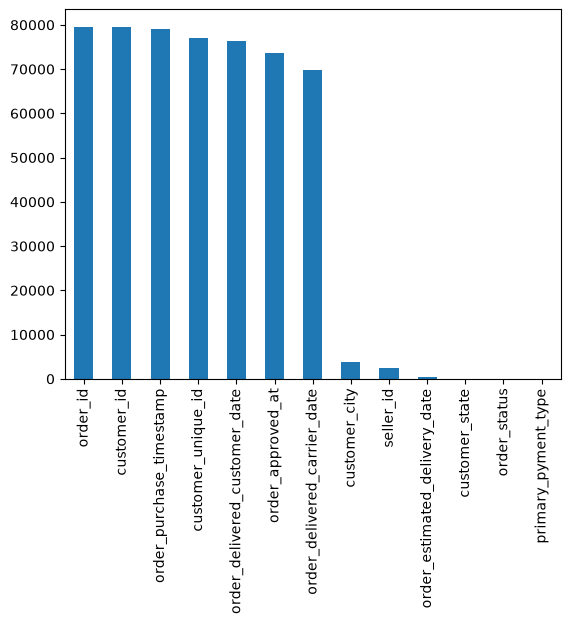

In [43]:
# Number of labels: Cardinality
cardinalith=train_df[categorical_features].nunique().sort_values(ascending=False)
print(cardinalith / train_df.shape[0])
save_chart('cardinality.png')
cardinalith.plot.bar();

### Relations between features and target (is_late)


In [44]:
# Mean of each numerical feature split by is_late
groupby_target=train_df.groupby("is_late")[numerical_features].mean().T
groupby_target["diff_pct"]=((groupby_target[1] - groupby_target[0]) / groupby_target[0] *100).round(2)
groupby_target=groupby_target.sort_values("diff_pct",key=abs,ascending=False)
print(groupby_target)

is_late                              0             1  diff_pct
avg_review_score              4.188851      2.448183    -41.55
total_freight                22.069532     25.143693     13.93
min_item_price              123.468373    139.624727     13.09
customer_zip_code_prefix  35287.536097  39784.974574     12.75
avg_item_price              124.083411    139.850507     12.71
max_item_price              124.787811    140.076211     12.25
total_pyment_value          158.632585    174.235774      9.84
total_price                 136.202631    149.058319      9.44
max_installments              2.946528      3.099368      5.19
total_items                   1.146326      1.113169     -2.89


## Dates (Purchase Timing)

In [45]:
# parse all date columns
date_cols=["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]

for col in date_cols:
    train_df[col]=pd.to_datetime(train_df[col],errors="coerce")

# Derived time features
train_df["purchase_month"]=train_df["order_purchase_timestamp"].dt.month
train_df["purchase_weekday"]=train_df["order_purchase_timestamp"].dt.day_name()
train_df["purchse_hour"]=train_df["order_purchase_timestamp"].dt.hour

# Delivery duration 
train_df["delivery_days"]=(train_df["order_delivered_customer_date"] - train_df["order_purchase_timestamp"]).dt.days
train_df["days_vs_estimate"] = (train_df["order_delivered_customer_date"] - train_df["order_estimated_delivery_date"]).dt.days
print(train_df[["delivery_days", "days_vs_estimate"]].describe())

       delivery_days  days_vs_estimate
count   76980.000000      76980.000000
mean       13.045038        -11.495207
std        10.048999         10.257563
min         0.000000       -147.000000
25%         7.000000        -16.000000
50%        11.000000        -12.000000
75%        16.000000         -7.000000
max       209.000000        188.000000


In [46]:
# Late rate by purchase month
month_late_rate=train_df.groupby("purchase_month")["is_late"].agg(["mean","count"])
print(month_late_rate)

                    mean  count
purchase_month                 
1               0.060354   8069
2               0.129525   8508
3               0.165572   9893
4               0.058011   9343
5               0.070284   9675
6               0.037288   3245
7               0.033035   4026
8               0.032094   4331
9               0.050595   4289
10              0.048436   4955
11              0.138256   7544
12              0.081424   5674


In [47]:
# Late rate by weekday of purchase
weekday_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_late_rate=train_df.groupby("purchase_weekday")["is_late"].mean().reindex(weekday_order)
print(weekday_late_rate)

purchase_weekday
Monday       0.093784
Tuesday      0.087267
Wednesday    0.082796
Thursday     0.078709
Friday       0.089757
Saturday     0.084641
Sunday       0.079803
Name: is_late, dtype: float64


In [48]:
# Late rate by customer state
state_status=train_df.groupby("customer_state").agg(
    order_count=("is_late","count"),
    late_rate=("is_late","mean")
).sort_values("order_count",ascending=False)
print(state_status.head(15))

plt.figure(figsize=(12,6))
top_states=state_status.head(15).sort_values("late_rate",ascending=False)
sns.barplot(x=top_states.index,y=top_states["late_rate"])
plt.title("Late Rate by Customer State (Top 15 States by Order Volume)")
plt.xlabel("Customer State")
plt.ylabel("Late Rate")
plt.tight_layout()
save_chart('state status.png')
plt.show()

                order_count  late_rate
customer_state                        
SP                    32511   0.052967
RJ                    10560   0.148390
MG                     9455   0.063882
RS                     4502   0.079520
PR                     4044   0.054896
SC                     3003   0.109890
BA                     2723   0.155343
DF                     1666   0.079232
ES                     1665   0.135135
GO                     1665   0.088889
PE                     1321   0.119606
CE                     1113   0.174304
PA                      812   0.140394
MT                      753   0.077025
MA                      628   0.199045


Saved: eda_charts\state status.png


In [49]:
train_df["zip_region"]=train_df["customer_zip_code_prefix"].astype(str).str[0]

zip_stats=train_df.groupby("zip_region").agg(
    order_count=("is_late","count"),
    late_rate=("is_late","mean")
).sort_values("zip_region")
print(zip_stats)

plt.figure(figsize=(8,5))
sns.barplot(x=zip_stats.index,y=zip_stats["late_rate"])
plt.title("Late Rate by ZIP Code Region (First Digit of Prefix)")
plt.xlabel("Zip Region (First Digit)")
plt.ylabel("Late Rate")
plt.tight_layout()
save_chart('code prefix.png')
plt.show()

            order_count  late_rate
zip_region                        
1                 15367   0.054858
2                 13892   0.136553
3                 11576   0.059865
4                  6400   0.099062
5                  4949   0.096787
6                  5473   0.109081
7                  6434   0.078489
8                  8819   0.078127
9                  6642   0.070310
Saved: eda_charts\code prefix.png


## Summary of Results
1. Dataset Dimensions & Memory:

    Rows: 79,552 records.

    Columns: 24 variables.

    Memory Usage: ~73.43 MB raw memory footprint (~14.6 MB indexed).
2. Missing Values Analysis:

    Highest Missingness: order_delivered_customer_date has the highest missing count with 2,572 missing values (3.23%), followed by order_delivered_carrier_date with 1,550 missing values (1.95%).

    Order Item Details: Financial and order metrics (total_price, max_item_price, min_item_price, avg_item_price, total_freight, total_items, seller_id) each have 669 missing values (0.84%).

    Ratings & Approval: avg_review_score has 667 missing values (0.84%), and order_approved_at has 87 missing values (0.11%).

    Payment Information: Payment fields (primary_pyment_type, max_installments, total_pyment_value) have only 1 missing value (0.00%).
    
3. Data Integrity & Target Variable:

    Duplicates: 0 duplicate rows found in the dataset.

    Target Distribution (is_late): Highly imbalanced class distribution where 91.4% (0.914) of orders were delivered on time (is_late = 0) and 8.6% (0.086) were delivered late (is_late = 1).

In [ ]:
train_df.to_csv("train_processed.csv", index=False)